# ReGRID model analysis

### Capacity and operations of technologies

Developed: 30 January, 2026

Note:
- This notebook depends on output files generated by the following notebooks:
  - model.py
  - analysis_system.ipynb

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.lines as lines

In [2]:
# Case setting
TERM = '1y' # Analysis term: 1y=Yearly
STEP = 6 # Timestep(h)
VER = 'v8' # Model version
YEAR = 2050 # Target year
BOUNDARY = 'japan' # Spatial boundary
NETWORK = '1741' # TSN:Transmission, '1741':Municipality
PATHWAY = 'C1' # Socioeconomic and emission pathway: C1:1.5C, C7:below 4C
POTENTIAL_AVAILABILITY = 100 # Uniform availability of renewable energy(%)
POTENTIAL_CASE = 'base' # Renewable energy potential assumptions ('base':HPA, 'low':PA+OECM, 'mid':Enhanced, 'high':FullProtect)
COST_CASE = 'moderate' # Cost assumption

TECH_CASE = 'ccs-biomass'
if TECH_CASE == 'ccs-biomass':
    CCS_AVAILAVILITY = 2 # 0:Not available, 1:Unlimited, 2:Only domestic
    NUCLEAR_AVAILABILITY = 2 # 0:Not available, 1:Available, 2:No new installation
    BIOMASS_CAP = 0.1 # Availability of technical potential
else:
    CCS_AVAILAVILITY = 1 # 0:Not available, 1:Unlimited, 2:Only domestic
    NUCLEAR_AVAILABILITY = 1 # 0:Not available, 1:Available, 2:No new installation
    BIOMASS_CAP = 1 # Availability of technical potential

In [3]:
# Initialize a model
def get_model_name(ver=VER, year=YEAR, pathway=PATHWAY, term=TERM, step=STEP, boundary=BOUNDARY, network=NETWORK, nuclear=NUCLEAR_AVAILABILITY, potential=POTENTIAL_AVAILABILITY, potential_case=POTENTIAL_CASE, cost_case=COST_CASE, tech_case=TECH_CASE):
    return f"ReGRID2_{ver}_{year}_{pathway}_{term}_{step}_{boundary}_{network}_n{nuclear}_p{potential}_{potential_case}_{cost_case}_{tech_case}"

model_name = get_model_name()
print(model_name)

ReGRID2_v8_2050_C1_1y_6_japan_1741_n2_p100_base_moderate_ccs-biomass


In [4]:
# Data for analysis

CASES = ['base','low','mid','high']
CASE_NAME = {'low':'PA+OECM', 'mid':'Enhanced', 'high':'FullProtect', 'sea':'MarineProtect', 'land':'LandProtect', 'base':'HPA'}

# Technology dataset
P = pd.read_csv(f'input/technology/technology_{PATHWAY}.csv', index_col=0)
P = P[(P['year'] == YEAR) & (P['scenario'] == COST_CASE)]

# Region list
region_list = pd.read_csv('input/region.csv', index_col='code', dtype={'code':str, 'DSN':str})
REGION = region_list.index.to_list() # All nodes

# JPY -> USD
USD = 107 # TTM in 2020

output_path = 'output/analysis'

In [5]:
# Chart paramter
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['font.size'] = 5
plt.rcParams['xtick.labelsize'] = 5
plt.rcParams['ytick.labelsize'] = 5
plt.rcParams['axes.linewidth'] = 0.5

MAX_WIDTH = 180 / 25.4 # inch in 180mm

In [6]:
# Transmission

grid_CF = pd.DataFrame()
grid_TWkm = pd.Series()
for case in CASES:
    case_name = get_model_name(potential_case=case)
    grid_data = pd.read_csv('output/%s/grid_%s.csv' % (case_name,case_name))
    grid_CF[case] = grid_data['CF'].round(2)
    grid_TWkm[case] = grid_data['MWkm'].sum() / 1000000

grid_TWkm

base    62.725196
low     62.231869
mid     63.757730
high    77.695730
dtype: float64

In [7]:
# Generator

DISPATCH = ['gas-c','gas-p','beccs','woody']
VRE = ['solar', 'onwin', 'of-fx', 'of-fl']
TECH = ['el-h2','daccs','stbat','stpcs']


# Dispatchable power
generator_CF = {}
generator_GW = {}
for tech in DISPATCH+VRE+TECH:
    generator_CF[tech] = pd.DataFrame()
    generator_GW[tech] = pd.Series()

for case in CASES:
    case_name = get_model_name(potential_case=case)
    CF_data = pd.read_csv('output/%s/CF_%s.csv' % (case_name,case_name)).round(2)
    capacity_data = pd.read_csv('output/%s/capacity_%s.csv' % (case_name,case_name), index_col=0)
    
    for tech in DISPATCH+TECH:
        generator_CF[tech][case] = CF_data[tech].dropna()
        generator_GW[tech][case] = capacity_data['MW'][tech] / 1000


# Renewables
profile = {}
profile["solar"] = pd.read_csv('input/%sh/solar_2019.csv' % (STEP), index_col=0)
profile["onwin"] = pd.read_csv('input/%sh/onwind_2019.csv' % (STEP), index_col=0)
profile["of-fx"] = pd.read_csv('input/%sh/ofwind_2019_fixed.csv' % (STEP), index_col=0)
profile["of-fl"] = pd.read_csv('input/%sh/ofwind_2019_float.csv' % (STEP), index_col=0)
profile["river"] = pd.read_csv('input/%sh/river_2019.csv' % (STEP), index_col=0)
profile["geoth"] = pd.read_csv('input/%sh/geothermal_2019.csv' % (STEP), index_col=0)
profile["hydro"] = pd.read_csv('input/%sh/hydro_2019.csv' % (STEP), index_col=0)
CF_annual = {}
for res in profile.keys():
    CF_annual[res] = (profile[res] / STEP).mean()

for case in CASES:
    case_name = get_model_name(potential_case=case)
    capacity_data = pd.read_csv('output/%s/capacity_region_%s.csv' % (case_name,case_name), index_col=0, dtype={'region':str})
    
    for tech in VRE:
        generator_GW[tech][case] = capacity_data[(capacity_data['value'] > 0) & (capacity_data['general'] == tech)]['value']
        generator_CF[tech][case] = CF_annual[tech][generator_GW[tech][case].index]
        
        generator_GW[tech][case] = generator_GW[tech][case].sum() / 1000

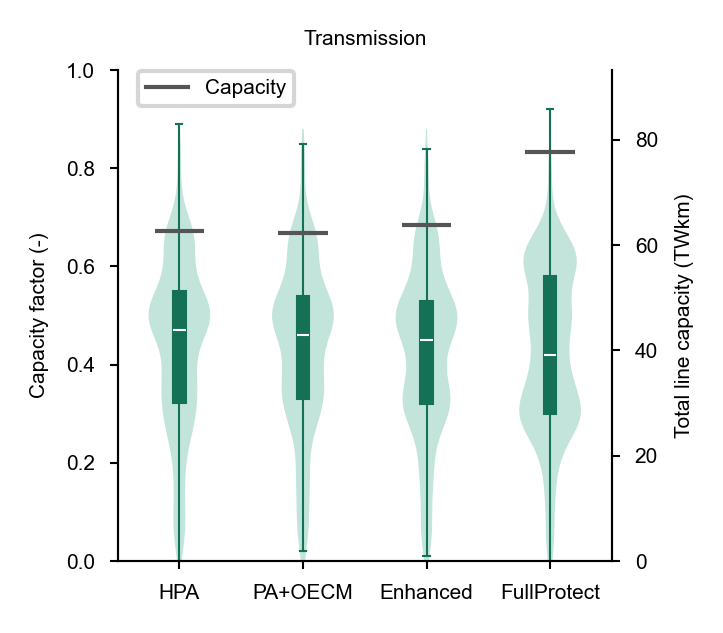

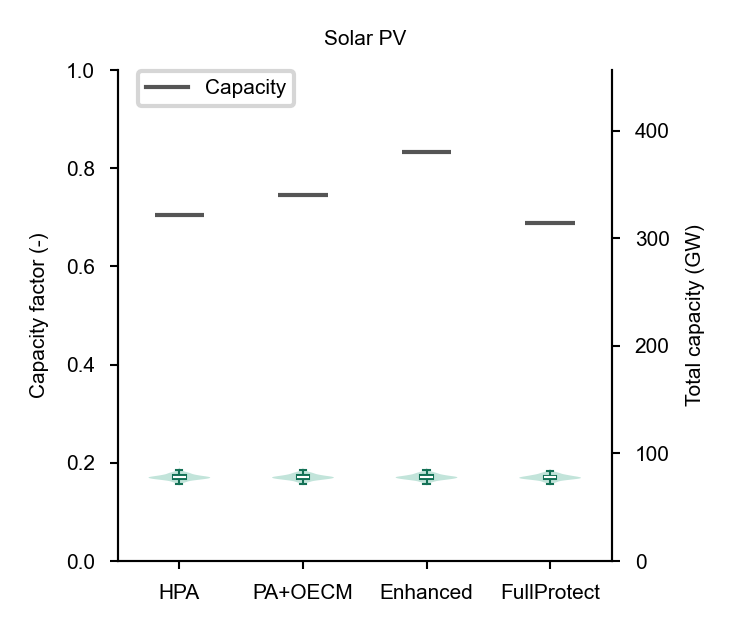

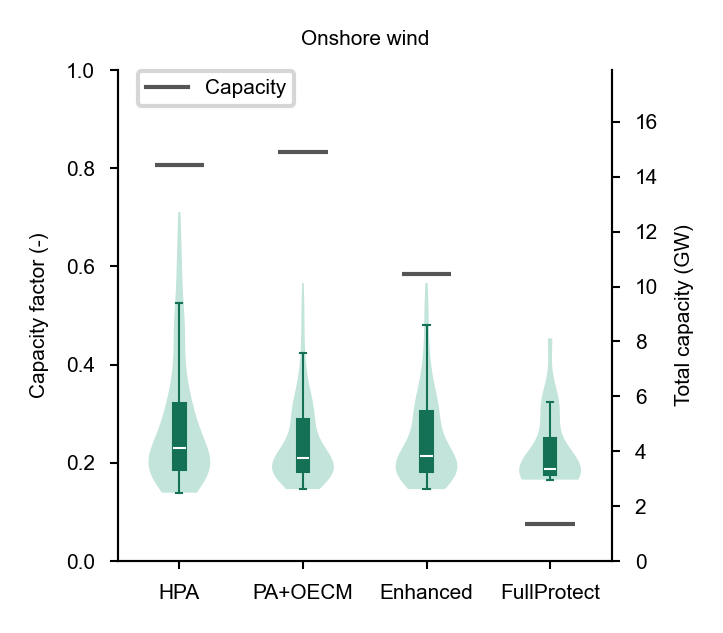

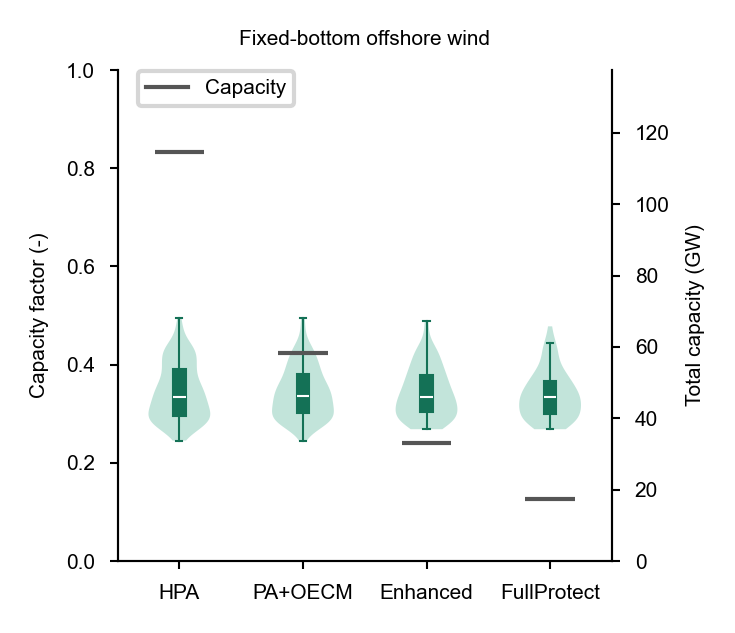

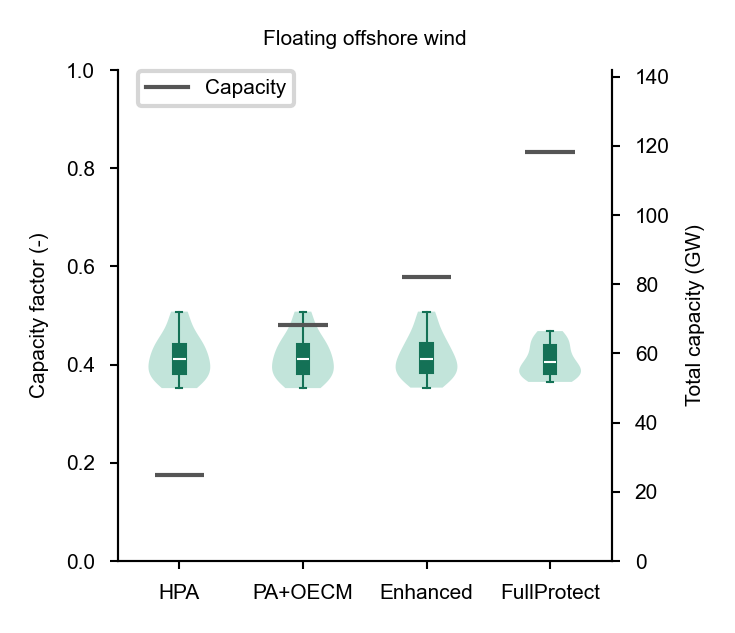

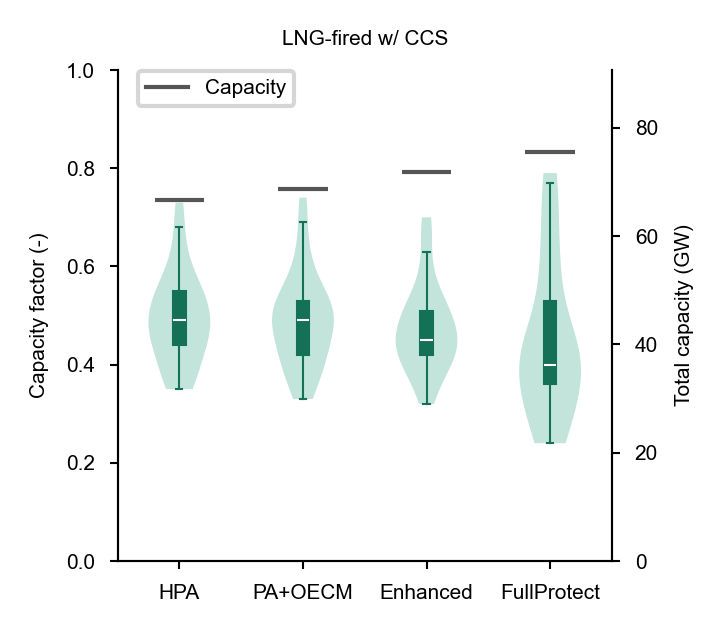

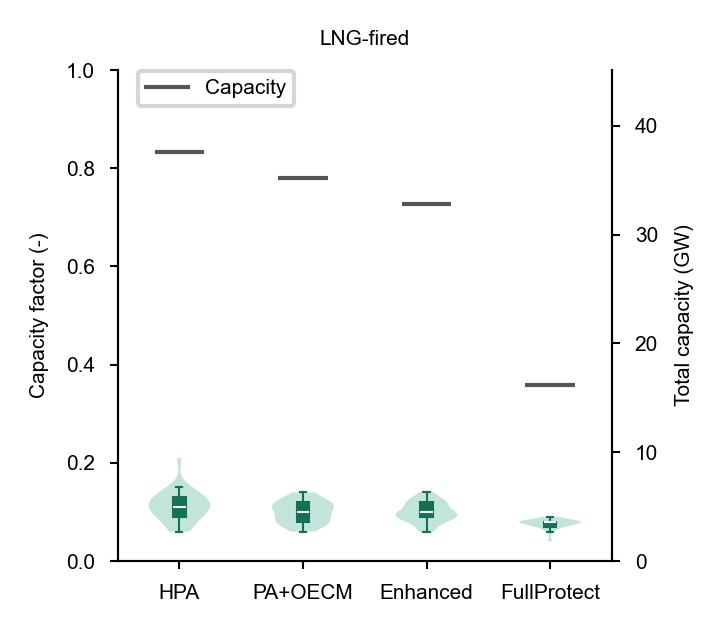

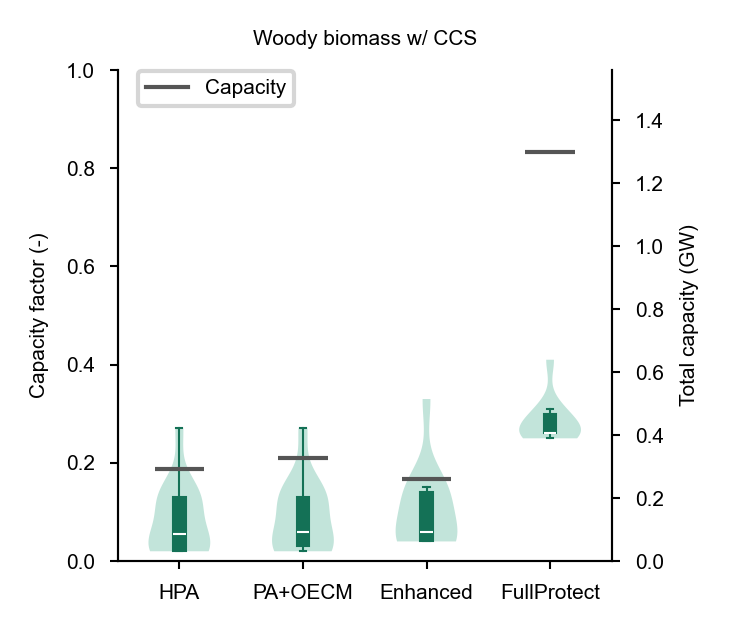

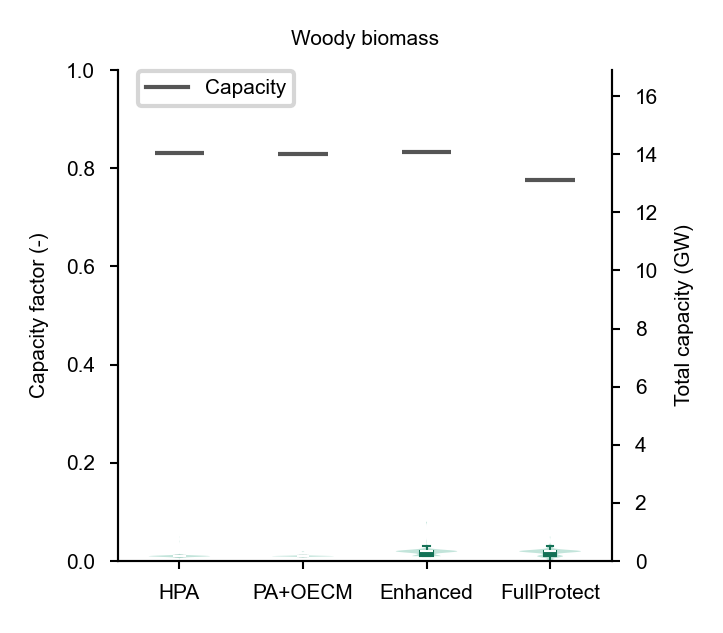

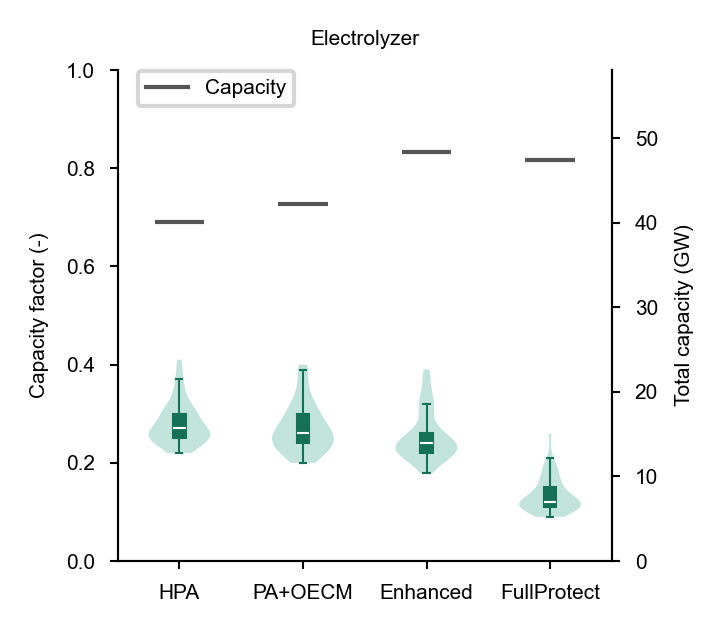

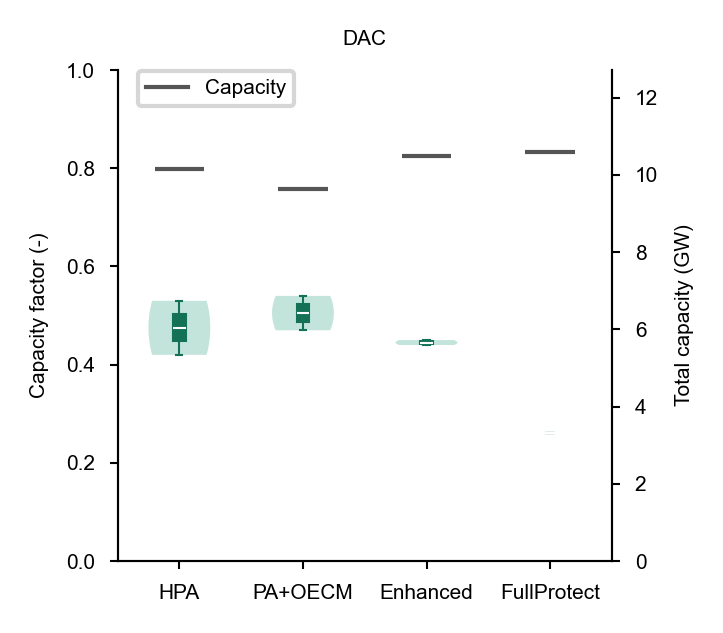

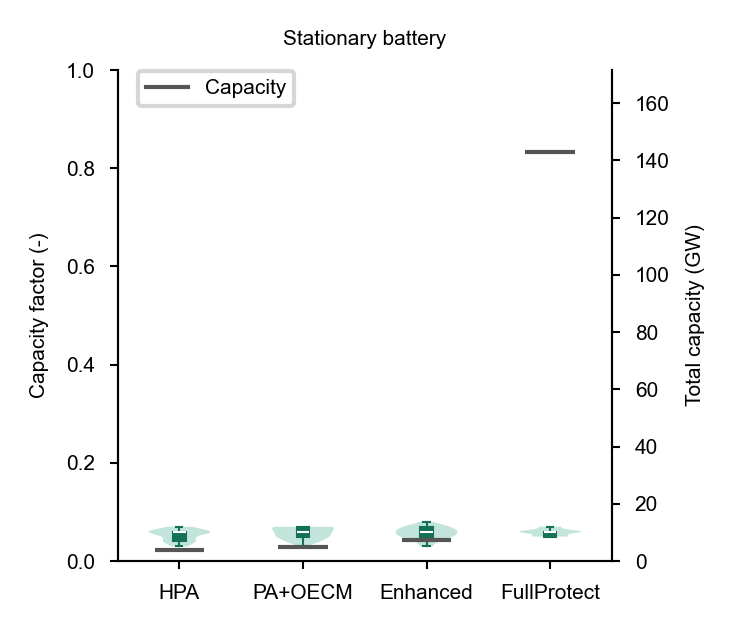

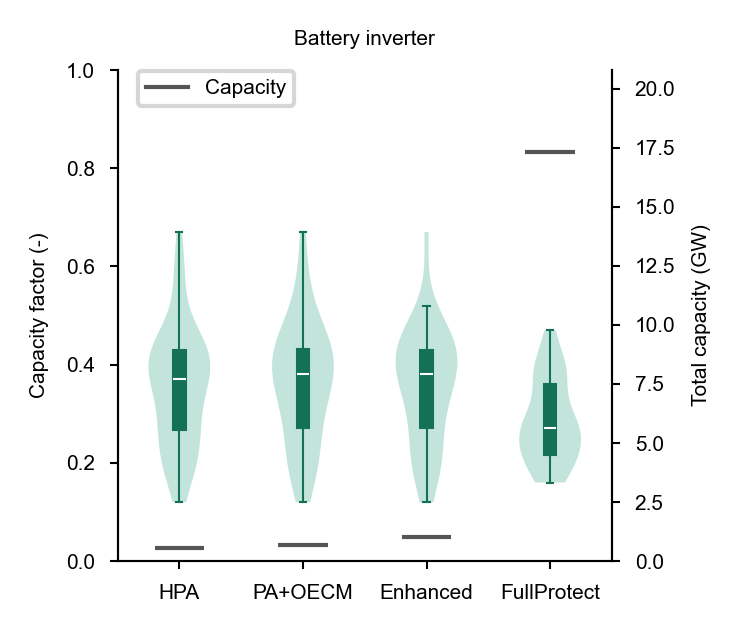

In [8]:
# Box plot

def violin_hline_plot(violin_data, line_data, title, ylabel_left, ylabel_right, fig_title):
    fig, ax = plt.subplots(1, 1, figsize=[MAX_WIDTH*0.3,MAX_WIDTH*0.3], dpi=300)
        
    box_color = "#147156"
    violin_color = "#67BCA4"

    # Boxplot
    ax.boxplot([violin_data[v].dropna() for v in violin_data], positions=[0,1,2,3], widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=box_color, color=box_color, linewidth=0.5),
                whiskerprops=dict(color=box_color, linewidth=0.5),
                capprops=dict(color=box_color, linewidth=0.5),
                medianprops=dict(color='#fff', linewidth=0.5),
                flierprops=dict(marker='o', markersize=0))
    
    # Violinplot
    violin = ax.violinplot([violin_data[v].dropna() for v in violin_data], positions=[0,1,2,3], widths=0.5, bw_method="scott", showmeans=False, showextrema=False, showmedians=False)
    for body in violin['bodies']:
        body.set_color(violin_color)
        body.set_edgecolor("none")
        body.set_alpha(0.4)

    # Holizontal line plot
    ax2 = ax.twinx()
    for n, y in enumerate(line_data, start=0):
        ax2.hlines(y=y, xmin=n-0.2, xmax=n+0.2, color='#555', linestyle='-', linewidth=1)

    # Setting
    ax.set_title(title if title != 'DACCS' else 'DAC', fontsize=5)
    ax.set_xticklabels([CASE_NAME[case] for case in CASES])
    ax.set_ylim(0, 1)
    ax2.set_ylim(0, max(line_data)*1.2)
    ax.set_ylabel(ylabel_left)
    ax2.set_ylabel(ylabel_right)
    ax.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    threshold_handle = lines.Line2D([], [], color='#555', linestyle='-', linewidth=1, label="Capacity")
    ax.legend(handles=[threshold_handle], loc='upper left', fontsize=5, frameon=True, bbox_to_anchor=(0.02, 1.02))

    plt.savefig(f"{output_path}/{fig_title}.png", bbox_inches='tight', pad_inches=0, transparent=False, dpi=1200)
    plt.savefig(f"{output_path}/{fig_title}.pdf", bbox_inches='tight', pad_inches=0, transparent=False)
    plt.show()

    
violin_hline_plot(grid_CF, grid_TWkm, 'Transmission', 'Capacity factor (-)', 'Total line capacity (TWkm)', 'comparison_C1_2050_transmission')

for tech in VRE+DISPATCH+TECH:
    violin_hline_plot(generator_CF[tech], generator_GW[tech], P['name'][tech], 'Capacity factor (-)', 'Total capacity (GW)', f'comparison_C1_2050_{tech}')
